In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from ipywidgets import IntSlider, Play, HBox, VBox, jslink, interact
from IPython.display import display


In [ ]:
"""
Animate CHIRPS daily rainfall over the Indian subcontinent.
"""

import matplotlib.animation as animation


# --- 1. Subset to India and to the time window you want to animate ---
india = xr.open_dataset("chirps_india_subset.nc")

# Edit this window: a full JJAS season will make ~120 frames, a fine
# starting point is one monsoon month so the file stays small and fast.
india_sub = india.sel(time=slice('2025-01-01', '2025-12-01'))
precip = india_sub.precip

# --- 2. Fix the color scale across all frames ---
# Without this, each frame renormalizes to its own min/max and the
# animation stops being comparable day to day. vmax is set to the 99th
# percentile (not the raw max) so a single extreme day doesn't wash out
# every other frame's contrast.
vmin = 0.0
vmax = float(precip.quantile(0.99))

# --- 3. Build the figure once, then update it in place ---
fig, ax = plt.subplots(figsize=(10, 6))

im = precip.isel(time=0).plot(
    ax=ax,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
    cbar_kwargs={'label': 'Precipitation (mm/day)'},
)
title = ax.set_title('')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
plt.tight_layout()

n_frames = precip.sizes['time']


def update(frame_idx):
    frame = precip.isel(time=frame_idx).values
    im.set_array(frame.ravel())
    date_str = str(precip.time.isel(time=frame_idx).values)[:10]
    title.set_text(f'Rainfall over the Indian subcontinent (CHIRPS) — {date_str}')
    return im, title


anim = animation.FuncAnimation(
    fig, update, frames=n_frames, interval=200, blit=False
)

# PillowWriter has no external dependency (no ffmpeg needed) and always
# works. If ffmpeg is installed, swap writer='ffmpeg' and save as .mp4
# instead — much smaller file size for longer time ranges.
anim.save('india_rainfall_june2025.gif', writer='pillow', fps=5)
plt.close(fig)

print(f"Saved animation with {n_frames} frames to india_rainfall_june2025.gif")

Saved animation with 12 frames to india_rainfall_june2025.gif


In [19]:
india

<xarray.Dataset>
Dimensions:    (latitude: 700, longitude: 800, time: 547)
Coordinates:
  * latitude   (latitude) float32 5.025 5.075 5.125 5.175 ... 39.87 39.92 39.97
  * longitude  (longitude) float32 60.02 60.07 60.12 60.18 ... 99.88 99.92 99.98
  * time       (time) datetime64[ns] 1981-01-01 1981-02-01 ... 2026-07-01
Data variables:
    precip     (time, latitude, longitude) float32 ...
Attributes: (12/14)
    Conventions:       CF-1.6
    title:             CHIRPS Version 3.0
    history:           created by Climate Hazards Center
    version:           Version 3.0
    data_created:      2026-08-14
    creator_name:      Pete Peterson
    ...                ...
    documentation:     http://pubs.usgs.gov/ds/832/
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    acknowledgements:  The Climate Hazards Center InfraRed Precipitation with...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/chg/products/CHIRPS...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

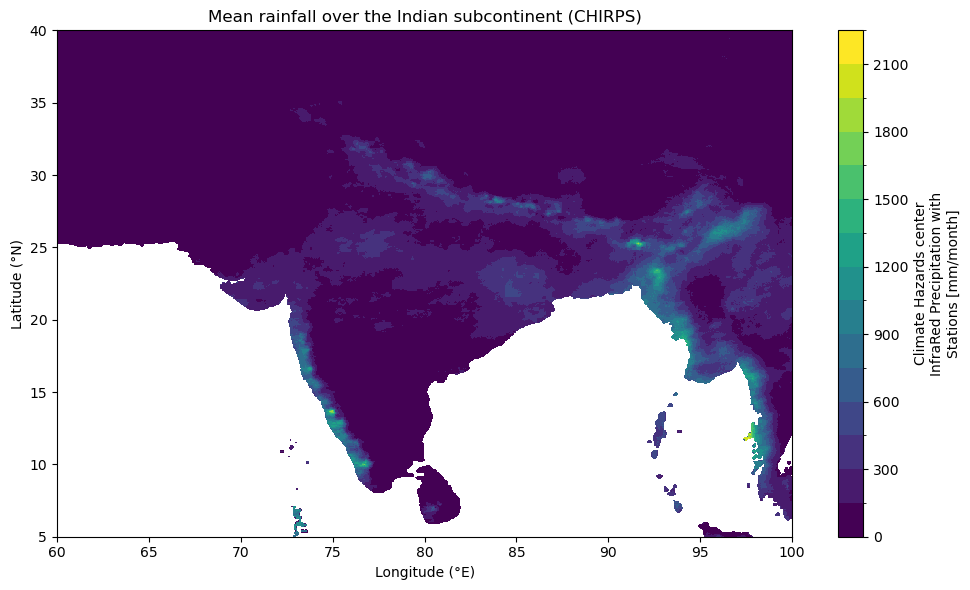

In [28]:
"""Spatial subset for the Indian subcontinent.
Lat/Lon bounds used: 5°N to 40°N and 60°E to 100°E.
"""
india = data.sel(latitude=slice(5, 40), longitude=slice(60, 100))

india.sel(time='2025-06-01').precip.plot(
    cmap='viridis',
    figsize=(10, 6),
    levels=20,
    add_colorbar=True,
)
plt.title('Mean rainfall over the Indian subcontinent (CHIRPS)')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.tight_layout()


In [5]:
# Save India subset to a new NetCDF file
india.to_netcdf('chirps_india_subset.nc')

In [14]:
import numpy as np
import xarray as xr
import torch
import matplotlib.pyplot as plt
import networkx as nx

from scipy.ndimage import gaussian_filter, maximum_filter


# ============================================================
# USER CONFIGURATION
# ============================================================

NC_FILE = "chirps_india_subset.nc"

# Change this to the actual variable in your NetCDF
RAIN_VAR = "precip"

# If your data has time:
TIME_INDEX = "2025-07-01"

# Rainfall below this is considered dry/background.
# Change according to your units.
RAIN_THRESHOLD = 0.1

# Gaussian smoothing.
# 0.0 = no smoothing
SMOOTH_SIGMA = 1.0

# Number of important critical points to retain
N_MAJOR = 15

# Minimum persistence relative to the largest persistence.
# 0.05 means discard features below 5% of maximum persistence.
PERSISTENCE_FRACTION = 0.05


# ============================================================
# 1. LOAD NETCDF
# ============================================================
def load_rainfall(
    nc_file,
    rain_var="precip",
    time_index=0,
    time_value=None,
):
    """
    Load one 2D rainfall field from the CHIRPS NetCDF dataset.

    Dataset expected:
        precip(time, latitude, longitude)

    Parameters
    ----------
    nc_file : str
        Path to NetCDF file.

    rain_var : str
        Rainfall variable name.

    time_index : int or None
        Integer positional index of the time slice.

    time_value : str/datetime or None
        Specific date, e.g. "2020-07-01".
        If supplied, this is used instead of time_index.
    """

    ds = xr.open_dataset(nc_file)

    print(ds)

    if rain_var not in ds.data_vars:
        raise ValueError(
            f"Variable '{rain_var}' not found. "
            f"Available variables: {list(ds.data_vars)}"
        )

    da = ds[rain_var]

    # --------------------------------------------------
    # Check dimensions
    # --------------------------------------------------
    print("\nRainfall dimensions:", da.dims)
    print("Rainfall shape:", da.shape)

    # --------------------------------------------------
    # Select time
    # --------------------------------------------------
    if "time" in da.dims:

        if time_value is not None:
            # Select by actual date
            da = da.sel(time=time_value)

        elif time_index is not None:
            # Select by integer position
            if not isinstance(time_index, (int, np.integer)):
                raise TypeError(
                    f"time_index must be an integer when using isel(). "
                    f"Got {type(time_index)}: {time_index}"
                )

            if time_index < 0 or time_index >= da.sizes["time"]:
                raise IndexError(
                    f"time_index={time_index} is invalid. "
                    f"Valid range: 0 ... {da.sizes['time'] - 1}"
                )

            da = da.isel(time=time_index)

    # --------------------------------------------------
    # Remove dimensions of length 1
    # --------------------------------------------------
    da = da.squeeze()

    # --------------------------------------------------
    # Make sure result is 2D
    # --------------------------------------------------
    if da.ndim != 2:
        raise ValueError(
            f"Expected a 2D rainfall field after time selection, "
            f"but got shape {da.shape} with dimensions {da.dims}"
        )

    # --------------------------------------------------
    # Convert to numpy
    # --------------------------------------------------
    rainfall = da.values.astype(np.float32)

    print("\nSelected rainfall:")
    print("Shape:", rainfall.shape)
    print("Min:", np.nanmin(rainfall))
    print("Max:", np.nanmax(rainfall))
    print("Mean:", np.nanmean(rainfall))

    # Coordinates
    lat = da["latitude"].values if "latitude" in da.coords else None
    lon = da["longitude"].values if "longitude" in da.coords else None

    selected_time = da["time"].values if "time" in da.coords else None

    print("Selected time:", selected_time)

    return rainfall, lat, lon, selected_time


# ============================================================
# 2. PREPROCESS RAINFALL
# ============================================================

def preprocess_rainfall(
    rainfall,
    threshold=0.1,
    sigma=1.0
):
    """
    Handle NaNs, negative values, zeros and smoothing.

    Returns
    -------
    rain : processed rainfall
    wet_mask : True where rainfall is meaningful
    """

    rainfall = np.asarray(rainfall, dtype=np.float64)

    # --------------------------------------------------------
    # NaNs -> zero/background
    # --------------------------------------------------------

    rainfall = np.nan_to_num(
        rainfall,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # --------------------------------------------------------
    # Negative rainfall is physically meaningless
    # --------------------------------------------------------

    rainfall = np.maximum(rainfall, 0.0)

    # --------------------------------------------------------
    # Wet/dry mask
    # --------------------------------------------------------

    wet_mask = rainfall > threshold

    # --------------------------------------------------------
    # Smooth ONLY rainfall values
    # --------------------------------------------------------

    if sigma > 0:

        smoothed = gaussian_filter(
            rainfall,
            sigma=sigma
        )

    else:

        smoothed = rainfall.copy()

    # --------------------------------------------------------
    # Preserve dry background
    # --------------------------------------------------------

    smoothed[~wet_mask] = 0.0

    return smoothed, wet_mask


# ============================================================
# 3. FIND LOCAL MAXIMA
# ============================================================

def find_maxima(
    field,
    wet_mask,
    neighborhood=3
):
    """
    Find local rainfall maxima.

    These are candidate rainfall-cell centers.
    """

    local_max = maximum_filter(
        field,
        size=neighborhood,
        mode="nearest"
    )

    maxima_mask = (
        (field == local_max)
        & wet_mask
        & (field > 0)
    )

    y, x = np.where(maxima_mask)

    maxima = []

    for yy, xx in zip(y, x):

        maxima.append({
            "type": "maximum",
            "y": int(yy),
            "x": int(xx),
            "value": float(field[yy, xx])
        })

    return maxima


# ============================================================
# 4. GRADIENT FLOW
# ============================================================

NEIGHBORS = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1),
    (-1, -1),
    (-1, 1),
    (1, -1),
    (1, 1),
]


def steepest_neighbor(
    field,
    y,
    x,
    direction,
    wet_mask
):
    """
    Find steepest neighbor.

    direction = -1 : descend
    direction = +1 : ascend
    """

    H, W = field.shape

    current = field[y, x]

    best = None
    best_value = current

    for dy, dx in NEIGHBORS:

        yy = y + dy
        xx = x + dx

        if not (0 <= yy < H and 0 <= xx < W):
            continue

        # Don't flow through dry background
        if not wet_mask[yy, xx]:
            continue

        value = field[yy, xx]

        if direction == -1:

            if value < best_value:

                best_value = value
                best = (yy, xx)

        else:

            if value > best_value:

                best_value = value
                best = (yy, xx)

    return best


def trace_gradient(
    field,
    start,
    direction,
    wet_mask,
    max_steps=10000
):
    """
    Follow gradient trajectory.
    """

    trajectory = [start]

    current = start

    visited = {current}

    for _ in range(max_steps):

        nxt = steepest_neighbor(
            field,
            current[0],
            current[1],
            direction,
            wet_mask
        )

        if nxt is None:
            break

        if nxt in visited:
            break

        trajectory.append(nxt)
        visited.add(nxt)

        current = nxt

    return trajectory


# ============================================================
# 5. FIND SADDLES
# ============================================================

def find_saddles(
    field,
    wet_mask
):
    """
    Approximate saddle detection using sign changes
    around the 8-neighbourhood.
    """

    H, W = field.shape

    saddles = []

    for y in range(1, H - 1):

        for x in range(1, W - 1):

            if not wet_mask[y, x]:
                continue

            value = field[y, x]

            signs = []

            for dy, dx in NEIGHBORS:

                yy = y + dy
                xx = x + dx

                if not wet_mask[yy, xx]:
                    continue

                diff = field[yy, xx] - value

                if diff > 0:
                    signs.append(1)

                elif diff < 0:
                    signs.append(-1)

            if len(signs) < 4:
                continue

            changes = sum(
                signs[i] != signs[(i + 1) % len(signs)]
                for i in range(len(signs))
            )

            # 4 sign changes approximately corresponds
            # to a 2D saddle.
            if changes >= 4:

                saddles.append({
                    "type": "saddle",
                    "y": y,
                    "x": x,
                    "value": float(value)
                })

    return saddles


# ============================================================
# 6. MERGE NEARBY CRITICAL POINTS
# ============================================================

def cluster_points(
    points,
    min_distance=4
):
    """
    Remove nearby duplicate critical points.

    Keep the strongest point in each neighbourhood.
    """

    if len(points) == 0:
        return []

    points = sorted(
        points,
        key=lambda p: p["value"],
        reverse=True
    )

    selected = []

    for p in points:

        too_close = False

        for q in selected:

            d = np.sqrt(
                (p["x"] - q["x"]) ** 2
                +
                (p["y"] - q["y"]) ** 2
            )

            if d < min_distance:

                too_close = True
                break

        if not too_close:
            selected.append(p)

    return selected


# ============================================================
# 7. COMPUTE PERSISTENCE-LIKE SCORE
# ============================================================

def compute_maximum_persistence(
    field,
    maxima,
    wet_mask
):
    """
    Estimate persistence of rainfall maxima.

    For each maximum, follow steepest descent until
    reaching a low point.

    Persistence approximately:

        maximum_value - valley_value
    """

    results = []

    for maximum in maxima:

        start = (
            maximum["y"],
            maximum["x"]
        )

        trajectory = trace_gradient(
            field,
            start,
            direction=-1,
            wet_mask=wet_mask
        )

        endpoint = trajectory[-1]

        valley_value = field[
            endpoint[0],
            endpoint[1]
        ]

        persistence = (
            maximum["value"]
            - valley_value
        )

        item = maximum.copy()

        item["persistence"] = float(
            persistence
        )

        item["trajectory"] = trajectory

        results.append(item)

    return results


# ============================================================
# 8. SELECT MAJOR CRITICAL POINTS
# ============================================================

def select_major_points(
    maxima,
    saddles,
    n_major=15,
    persistence_fraction=0.05
):
    """
    Select a finite set of important critical points.

    Maxima are ranked by persistence.

    Saddles are ranked by their rainfall value.
    """

    # --------------------------------------------------------
    # Rank maxima by persistence
    # --------------------------------------------------------

    maxima = sorted(
        maxima,
        key=lambda p: p.get(
            "persistence", 0
        ),
        reverse=True
    )

    if len(maxima) > 0:

        max_persistence = max(
            p["persistence"]
            for p in maxima
        )

        min_persistence = (
            persistence_fraction
            * max_persistence
        )

        maxima = [
            p for p in maxima
            if p["persistence"]
            >= min_persistence
        ]

    # --------------------------------------------------------
    # Rank saddles by field value
    # --------------------------------------------------------

    saddles = sorted(
        saddles,
        key=lambda p: p["value"],
        reverse=True
    )

    # --------------------------------------------------------
    # Keep roughly half maxima and half saddles
    # --------------------------------------------------------

    n_max = n_major // 2

    n_saddle = n_major - n_max

    maxima = maxima[:n_max]
    saddles = saddles[:n_saddle]

    return maxima, saddles


# ============================================================
# 9. CREATE GRAPH
# ============================================================

def build_graph(
    field,
    maxima,
    saddles,
    wet_mask
):
    """
    Construct graph

        maximum -- saddle -- maximum

    based on gradient-flow basins.

    Nodes:
        M = maximum
        S = saddle

    Edges represent rainfall structures separated/
    connected through saddles.
    """

    G = nx.Graph()

    # --------------------------------------------------------
    # Add maxima
    # --------------------------------------------------------

    for i, p in enumerate(maxima):

        node_id = f"M{i}"

        G.add_node(
            node_id,
            type="maximum",
            x=p["x"],
            y=p["y"],
            value=p["value"],
            persistence=p.get(
                "persistence",
                0.0
            )
        )

    # --------------------------------------------------------
    # Add saddles
    # --------------------------------------------------------

    saddle_offset = len(maxima)

    for i, p in enumerate(saddles):

        node_id = f"S{i}"

        G.add_node(
            node_id,
            type="saddle",
            x=p["x"],
            y=p["y"],
            value=p["value"]
        )

    # --------------------------------------------------------
    # For each saddle, determine nearby maxima
    # --------------------------------------------------------

    for i, saddle in enumerate(saddles):

        saddle_id = f"S{i}"

        sy = saddle["y"]
        sx = saddle["x"]

        # Trace uphill from saddle
        trajectory = trace_gradient(
            field,
            (sy, sx),
            direction=+1,
            wet_mask=wet_mask
        )

        endpoint = trajectory[-1]

        # Find closest maximum
        distances = []

        for j, maximum in enumerate(maxima):

            d = np.sqrt(
                (endpoint[0] - maximum["y"]) ** 2
                +
                (endpoint[1] - maximum["x"]) ** 2
            )

            distances.append(
                (d, j)
            )

        distances.sort()

        # Connect saddle to nearest maxima
        for d, j in distances[:2]:

            G.add_edge(
                saddle_id,
                f"M{j}",
                distance=float(d),
                saddle_value=saddle["value"],
                trajectory=trajectory
            )

    return G


# ============================================================
# 10. PLOT
# ============================================================

def plot_rainfall_morse_graph(
    rainfall,
    G,
    title="Rainfall Morse-Smale Graph"
):
    """
    Plot rainfall field and graph simultaneously.
    """

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    # --------------------------------------------------------
    # Rainfall field
    # --------------------------------------------------------

    im = ax.imshow(
        rainfall,
        origin="lower",
        cmap="Blues"
    )

    plt.colorbar(
        im,
        ax=ax,
        label="Rainfall"
    )

    # --------------------------------------------------------
    # Edges / separatrices
    # --------------------------------------------------------

    for u, v, data in G.edges(
        data=True
    ):

        trajectory = data.get(
            "trajectory"
        )

        if trajectory is None:
            continue

        y = [
            p[0]
            for p in trajectory
        ]

        x = [
            p[1]
            for p in trajectory
        ]

        ax.plot(
            x,
            y,
            color="black",
            linewidth=2,
            zorder=4
        )

    # --------------------------------------------------------
    # Nodes
    # --------------------------------------------------------

    for node_id, data in G.nodes(
        data=True
    ):

        x = data["x"]
        y = data["y"]

        if data["type"] == "maximum":

            ax.scatter(
                x,
                y,
                s=150,
                marker="o",
                c="red",
                edgecolors="white",
                linewidths=2,
                zorder=10
            )

            ax.text(
                x + 2,
                y + 2,
                node_id,
                fontsize=10,
                weight="bold",
                zorder=11
            )

        elif data["type"] == "saddle":

            ax.scatter(
                x,
                y,
                s=120,
                marker="s",
                c="yellow",
                edgecolors="black",
                linewidths=2,
                zorder=10
            )

            ax.text(
                x + 2,
                y + 2,
                node_id,
                fontsize=10,
                weight="bold",
                zorder=11
            )

    ax.set_title(title)

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_aspect("equal")

    plt.tight_layout()

    return fig, ax


# ============================================================
# 11. PRINT GRAPH
# ============================================================

def print_graph(G):

    print("\n==============================")
    print("MORSE RAINFALL GRAPH")
    print("==============================")

    print("\nNODES:")

    for node_id, data in G.nodes(
        data=True
    ):

        print(
            f"{node_id:>4} | "
            f"{data['type']:>8} | "
            f"(x={data['x']:3d}, "
            f"y={data['y']:3d}) | "
            f"value={data['value']:.3f}"
        )

        if "persistence" in data:

            print(
                f"       persistence="
                f"{data['persistence']:.3f}"
            )

    print("\nEDGES:")

    for u, v, data in G.edges(
        data=True
    ):

        print(
            f"{u}  <---->  {v} "
            f"(distance={data['distance']:.2f})"
        )


# ============================================================
# 12. MAIN PIPELINE
# ============================================================

def main():

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    rainfall = load_rainfall(
        NC_FILE,
        RAIN_VAR,
        TIME_INDEX
    )

    print(
        "\nOriginal shape:",
        rainfall.shape
    )

    print(
        "Rainfall range:",
        np.nanmin(rainfall),
        np.nanmax(rainfall)
    )

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    rainfall, wet_mask = preprocess_rainfall(
        rainfall,
        threshold=RAIN_THRESHOLD,
        sigma=SMOOTH_SIGMA
    )

    # --------------------------------------------------------
    # Find maxima
    # --------------------------------------------------------

    maxima = find_maxima(
        rainfall,
        wet_mask
    )

    print(
        "\nRaw maxima:",
        len(maxima)
    )

    # Remove maxima that are too close
    maxima = cluster_points(
        maxima,
        min_distance=4
    )

    print(
        "Clustered maxima:",
        len(maxima)
    )

    # --------------------------------------------------------
    # Persistence
    # --------------------------------------------------------

    maxima = compute_maximum_persistence(
        rainfall,
        maxima,
        wet_mask
    )

    # --------------------------------------------------------
    # Saddles
    # --------------------------------------------------------

    saddles = find_saddles(
        rainfall,
        wet_mask
    )

    saddles = cluster_points(
        saddles,
        min_distance=4
    )

    print(
        "Candidate saddles:",
        len(saddles)
    )

    # --------------------------------------------------------
    # Select major structures
    # --------------------------------------------------------

    maxima, saddles = select_major_points(
        maxima,
        saddles,
        n_major=N_MAJOR,
        persistence_fraction=PERSISTENCE_FRACTION
    )

    print(
        "\nSelected maxima:",
        len(maxima)
    )

    print(
        "Selected saddles:",
        len(saddles)
    )

    # --------------------------------------------------------
    # Build graph
    # --------------------------------------------------------

    G = build_graph(
        rainfall,
        maxima,
        saddles,
        wet_mask
    )

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print_graph(G)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plot_rainfall_morse_graph(
        rainfall,
        G
    )

    plt.show()

    return rainfall, wet_mask, G




In [ ]:
rainfall, lat, lon, selected_time = load_rainfall(
    NC_FILE,
    rain_var="precip",
    time_value="2020-07-01"
)


IndentationError: unexpected indent (1396872803.py, line 16)

In [18]:
rainfall, wet_mask = preprocess_rainfall(
    rainfall,
    threshold=RAIN_THRESHOLD,
    sigma=SMOOTH_SIGMA
)

# --------------------------------------------------------
# Find maxima
# --------------------------------------------------------

maxima = find_maxima(
    rainfall,
    wet_mask
)

print(
    "\nRaw maxima:",
    len(maxima)
)

# Remove maxima that are too close
maxima = cluster_points(
    maxima,
    min_distance=4
)

print(
    "Clustered maxima:",
    len(maxima)
)

# --------------------------------------------------------
# Persistence
# --------------------------------------------------------

maxima = compute_maximum_persistence(
    rainfall,
    maxima,
    wet_mask
)

# --------------------------------------------------------
# Saddles
# --------------------------------------------------------

saddles = find_saddles(
    rainfall,
    wet_mask
)

saddles = cluster_points(
    saddles,
    min_distance=4
)

print(
    "Candidate saddles:",
    len(saddles)
)

# --------------------------------------------------------
# Select major structures
# --------------------------------------------------------

maxima, saddles = select_major_points(
    maxima,
    saddles,
    n_major=N_MAJOR,
    persistence_fraction=PERSISTENCE_FRACTION
)

print(
    "\nSelected maxima:",
    len(maxima)
)

print(
    "Selected saddles:",
    len(saddles)
)

# --------------------------------------------------------
# Build graph
# --------------------------------------------------------

G = build_graph(
    rainfall,
    maxima,
    saddles,
    wet_mask
)

# --------------------------------------------------------
# Print
# --------------------------------------------------------

print_graph(G)


Raw maxima: 2280
Clustered maxima: 2160
Candidate saddles: 17531

Selected maxima: 7
Selected saddles: 8

MORSE RAINFALL GRAPH

NODES:
  M0 |  maximum | (x=633, y=404) | value=3672.717
       persistence=3389.936
  M1 |  maximum | (x=299, y=170) | value=2920.015
       persistence=2719.887
  M2 |  maximum | (x=309, y=147) | value=2444.169
       persistence=2331.224
  M3 |  maximum | (x=608, y=436) | value=2349.885
       persistence=2278.416
  M4 |  maximum | (x=309, y=161) | value=2374.173
       persistence=2262.784
  M5 |  maximum | (x=312, y=155) | value=2226.411
       persistence=2115.023
  M6 |  maximum | (x=270, y=293) | value=2244.816
       persistence=2030.120
  S0 |   saddle | (x=633, y=403) | value=3624.359
  S1 |   saddle | (x=630, y=406) | value=3062.795
  S2 |   saddle | (x=300, y=169) | value=2899.575
  S3 |   saddle | (x=299, y=173) | value=2883.319
  S4 |   saddle | (x=296, y=176) | value=2699.828
  S5 |   saddle | (x=626, y=406) | value=2524.771
  S6 |   saddle | 